###**Parametric Method**

The Parametric method calculates VaR by assuming the returns typically follow a random normal distribution with mean(μ) and std deviation (σ) of historical returns to estimate the potential losses at a given confidence interval (Z). This meethod computes portfolio variance using the covariance matrix, considering the Correlation between the assets in that portfolio.

It is a model-based quantile estimator, unlike Historical VaR which is empirical. It is also known as Variance - Covariance method or Delta normal method.

**Assumptions**
1. Individual Asset's Returns are normally distributed and Portfolio returns follows Multi Variate Normal distribution (symmetric bell shape curve, No Skewness).

 $$ r∼N(μ,σ^2) $$

2. Volatility, covariance and corelation between assets in a portfolio were stable


#### Value at Risk
$$ VaR = \mu - (\sigma * z)$$
#### Portfolio Mean (Expected Return) for 3 Assets
$$ \mu = E[R_p] = w_1 E[R_1] + w_2 E[R_2] + w_3 E[R_3] $$


#### Portfolio Standard Deviation (Matrix Form)
$$ \sigma_p = \sqrt({W^T \Sigma W}) $$

#### Covariance Between Two Assets ($R_i$, $R_j$)
$$ Cov(R_i, R_j) = E[(R_i - E[R_i])(R_j - E[R_j])] = \rho_{ij} \sigma_i \sigma_j $$

#### Covariance Matrix for 3 Assets
$$ \Sigma = \begin{pmatrix}
\sigma_1^2 & \rho_{12}\sigma_1\sigma_2 & \rho_{13}\sigma_1\sigma_3 \\
\rho_{12}\sigma_1\sigma_2 & \sigma_2^2 & \rho_{23}\sigma_2\sigma_3 \\
\rho_{13}\sigma_1\sigma_3 & \rho_{23}\sigma_2\sigma_3 & \sigma_3^2
\end{pmatrix} $$

#### Portfolio Variance for 3 Assets
$$ Var(R_p) = w_1^2 \sigma_1^2 + w_2^2 \sigma_2^2 + w_3^2 \sigma_3^2 + 2w_1 w_2 \rho_{12} \sigma_1 \sigma_2 + 2w_1 w_3 \rho_{13} \sigma_1 \sigma_3 + 2w_2 w_3 \rho_{23} \sigma_2 \sigma_3 $$


**Limitations**

* It is computationally efficient and suitable for linear portfolios, but it underestimates tail risk and fails during fat-tailed market events.
* Assumes normal distribution which Ignores fat tails and skewness
* Correlation Breakdown - Correlations increase during stress and Diversification benefits disappear when needed most - Major failure during: 2008 financial crisis,COVID shock
* Large portfolios require matrix optimization
* Correlation shocks matter - Correlation risk - if the correlation hits 1 (near positive correlation) the whole portfolio losing value will be higher than the predicted VaR.
* It Works Best on Stable markets, Linear portfolios, Low volatility regimes, Large diversified portfolios


In [2]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

In [4]:
tickers = ['CL=F','NG=F','GC=F','SI=F']
years = 1
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days= 365*years)

In [3]:
adj_close_df = pd.DataFrame()
for ticker in tickers:
  data = yf.download(tickers, start=startDate, end=endDate)
  adj_close_df[ticker] = data[('Close', ticker)]
print(adj_close_df)

/tmp/ipykernel_322/3166823856.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=startDate, end=endDate)
[*********************100%***********************]  4 of 4 completed
/tmp/ipykernel_322/3166823856.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=startDate, end=endDate)
[*********************100%***********************]  4 of 4 completed
/tmp/ipykernel_322/3166823856.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=startDate, end=endDate)
[*********************100%***********************]  4 of 4 completed
/tmp/ipykernel_322/3166823856.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=startDate, end=endDate)
[*********************100%***********************]  4 of 4 completed


                 CL=F   NG=F         GC=F       SI=F
Date                                                
2025-03-17  67.580002  4.018  3000.000000  34.074001
2025-03-18  66.900002  4.052  3035.100098  34.578999
2025-03-19  67.160004  4.247  3035.899902  33.974998
2025-03-20  68.260002  3.975  3040.000000  33.785999
2025-03-21  68.279999  3.980  3018.199951  33.290001
...               ...    ...          ...        ...
2026-03-10  83.449997  3.020  5229.700195  89.083000
2026-03-11  87.250000  3.209  5167.399902  85.065002
2026-03-12  95.730003  3.233  5115.799805  84.669998
2026-03-13  98.709999  3.131  5052.500000  80.914001
2026-03-15  98.709999  3.120  5019.399902  80.199997

[252 rows x 4 columns]


In [4]:
log_returns = np.log(adj_close_df / adj_close_df.shift(1))
log_returns = log_returns.dropna()
log_returns

,CL=F,NG=F,GC=F,SI=F
Date,,,,
2025-03-18,-0.010113,0.008426,0.011632,0.014712
2025-03-19,0.003879,0.047002,0.000263,-0.017622
2025-03-20,0.016246,-0.066188,0.001350,-0.005578
2025-03-21,0.000293,0.001257,-0.007197,-0.014789
2025-03-24,0.012083,-0.016722,-0.001691,-0.000751
...,...,...,...,...
2026-03-10,-0.127205,-0.032576,0.026781,0.058371
2026-03-11,0.044530,0.060703,-0.011984,-0.046153
2026-03-12,0.092754,0.007451,-0.010036,-0.004654


In [5]:
portfolio_value = 1000000
weights = np.array([1/len(tickers)]*len(tickers))
print(weights)
portfolio_returns = log_returns.dot(weights)
portfolio_returns

[0.25 0.25 0.25 0.25]


,0
Date,
2025-03-18,0.006164
2025-03-19,0.008381
2025-03-20,-0.013543
2025-03-21,-0.005109
2025-03-24,-0.001770
...,...
2026-03-10,-0.018657
2026-03-11,0.011774
2026-03-12,0.021379


In [6]:
days = 10
range_X_day_returns = portfolio_returns.rolling(window = days).sum()
range_X_day_returns = range_X_day_returns.dropna()
range_X_day_returns

,0
Date,
2025-03-31,0.033057
2025-04-01,0.013010
2025-04-02,0.017070
2025-04-03,-0.004953
2025-04-04,-0.067315
...,...
2026-03-10,0.077064
2026-03-11,0.072848
2026-03-12,0.119799


In [7]:
portfolio_mean = portfolio_returns.mean()
portfolio_std_dev = portfolio_returns.std()
print(f"Portfolio Mean = {portfolio_mean}")
print(f"Portfolio Std. dev = {portfolio_std_dev}")

Portfolio Mean = 0.00149064712440453
Portfolio Std. dev = 0.023179516621584607


          CL=F      NG=F      GC=F      SI=F
CL=F  0.160091  0.041282  0.006063  0.015562
NG=F  0.041282  1.125255  0.013650 -0.003426
GC=F  0.006063  0.013650  0.070911  0.129181
SI=F  0.015562 -0.003426  0.129181  0.405470
Portfolio Mean: 0.00149064712440453
Portfolio Standard deviation when considering Correlation: 0.36796341894840556


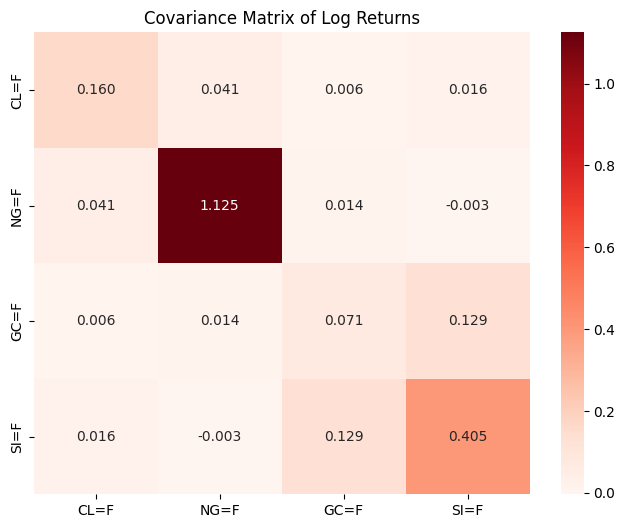

In [8]:
cov_matrix = log_returns.cov() * 252
print(cov_matrix)

portfolio_std_dev_correlation = np.sqrt(weights.T @ cov_matrix @ weights)
print(f'Portfolio Mean: {portfolio_mean}')
print(f'Portfolio Standard deviation when considering Correlation: {portfolio_std_dev_correlation}')


plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, fmt=".3f", cmap='Reds', xticklabels=tickers, yticklabels=tickers)
plt.title('Covariance Matrix of Log Returns')
plt.show()


In [9]:
confidence_intervals = [0.9,0.95,0.99]
VaRs = [portfolio_value * ((norm.ppf(1-cl) * portfolio_std_dev_correlation * np.sqrt(days/252)) - portfolio_mean*days) for cl in confidence_intervals]

VaR_results = pd.DataFrame({
    'Confidence Level': [f'{cl*100:.0f}%' for cl in confidence_intervals],
    'Value at Risk': VaRs
})
display(VaR_results)


,Confidence Level,Value at Risk
0,90%,-108844.287613
1,95%,-135474.353269
2,99%,-185427.927640


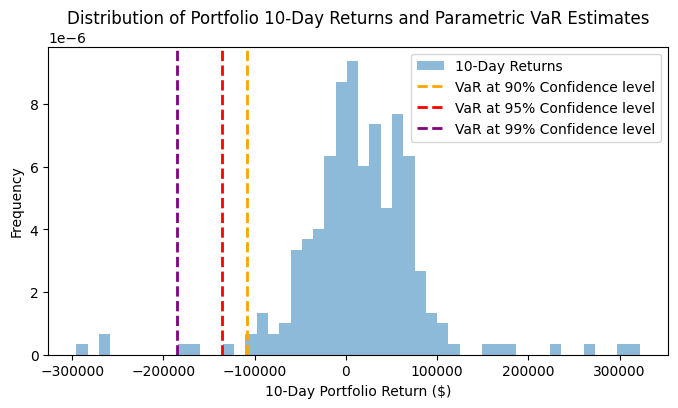

In [10]:
x_day_returns_dollar = range_X_day_returns * portfolio_value
plt.figure(figsize=(8, 4))
plt.hist(x_day_returns_dollar, bins=50, density=True, alpha=0.5, label=f'{days}-Day Returns')
plt.xlabel(f'{days}-Day Portfolio Return ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {days}-Day Returns and Parametric VaR Estimates')
colors = ['orange', 'red', 'purple']
for idx, ci in enumerate(confidence_intervals):
    plt.axvline(VaRs[idx], linestyle='dashed',
                linewidth=2, color=colors[idx],
                label=f'VaR at {ci*100:.0f}% Confidence level')
plt.legend()
plt.show()
